 ## Actividad 1 — Implementación manual de KNN con Iris
El objetivo de esta primera actividad es implementar el procedimiento de KNN sin utilizar KNeighborsClassifier de scikit learn

Dataset Iris
El dataset Iris es uno de los conjuntos de datos clásicos utilizados para introducir problemas de clasificación. Contiene 150 observaciones de flores, pertenecientes a tres especies:

Iris setosa
Iris versicolor
Iris virginica
Para cada flor se registran cuatro atributos morfológicos, medidos en centímetros: longitud y ancho del sépalo, y longitud y ancho del pétalo. Cada especie contiene 50 observaciones, por lo que las clases están equilibradas.

En esta práctica se utilizarán únicamente la longitud y el ancho del pétalo como atributos de entrada. Esto permite trabajar con una representación sencilla del problema mientras se implementa manualmente el algoritmo KNN.

El objetivo es predecir la especie de una flor a partir de sus características.

Se proporciona la estructura de una clase y el cálculo de la distancia. Completar el método predict().

Para cada punto de prueba deberá:

calcular la distancia a cada ejemplo de entrenamiento;
ordenar las distancias;
seleccionar los  K  vecinos más cercanos;
obtener sus clases;
realizar la votación;
agregar la clase predicha a y_pred.
Puede utilizar Counter para realizar la votación.

Utilizar:

K=3 
distancia Euclídea, es decir  p=2 
Calcular las predicciones sobre el conjunto de prueba y estimar la tasa de aciertos.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.datasets import load_iris, load_digits, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [3]:
iris_df = load_iris(as_frame=True).frame

X = iris_df[["petal length (cm)", "petal width (cm)"]].values
y = iris_df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=1,
    stratify=y
)

In [4]:
class KNN:
    """Clasificador KNN.

    Parámetros
    ------------
    k : int
        número de vecinos cercanos
    p : int
        valor para selección de métrica (1: Manhattan, 2: Euclídea)
    """

    def __init__(self, k=3, p=2):
        self.k = k
        self.p = p

    def distancia(self, vec_1, vec_2, p=2):
        dim = len(vec_1)
        distance=0
        for d in range(dim):
            distance += (abs(vec_1[d]-vec_2[d]))**p
        distance = (distance)**(1/p)
        return distance

    def fit(self, X, y):
        """Entrenamiento del clasificador kNN, es un algoritmo 'perezoso'
        sólo almacena los datos y sus etiquetas
        Parameters
        ----------
        X : array
            vector de características.
        y : array
            clases asociadas a los datos.
        """
        self.X = np.asarray(X)
        self.y = np.asarray(y)
        self.n_datos = X.shape[0]

    def predict(self, x):
        """Función que realiza la predicción.
        Parameters
        ----------
        x : array
            vector de patrones de entrada.
        Returns
        -------
        vector de predicciones.
        """
        y_pred = []

        for punto_prueba in x:
            distancias = []

            for dato_entrenamiento in self.X:
                distancias.append(
                    self.distancia(punto_prueba, dato_entrenamiento, self.p)
                )

            indices = np.argsort(distancias)
            vecinos = indices[:self.k]
            clases_vecinos = self.y[vecinos]

            clase_predicha = Counter(clases_vecinos).most_common(1)[0][0]

            y_pred.append(clase_predicha)

        return np.asarray(y_pred)

In [5]:
K = 3
p = 2

knn = KNN(k=K, p=p)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9777777777777777


El clasificador KNN implementado manualmente obtuvo una tasa de aciertos de aproximadamente 97,78 % sobre el conjunto de prueba. 
El resultado muestra un desempeño muy alto utilizando únicamente la longitud y el ancho del pétalo como atributos, con K = 3 y distancia Euclídea.


## Actividad 2 — KNN con scikit-learn : reconocimiento de dígitos

El objetivo de esta actividad es estudiar:

cómo cambia el resultado al utilizar Manhattan o Euclídea;
cómo influye el valor de K;
cómo seleccionar una configuración usando validación;
cómo interpretar una matriz de confusión multiclase.



2.1 Carga del dataset

Cargar el dataset Digits utilizando load_digits().


In [9]:
digits = load_digits()

X_digits = digits.data
y_digits = digits.target

print("X shape:", X_digits.shape)
print("Classes:", np.unique(y_digits))
print("Pixel value range:", (X_digits.min(), X_digits.max()))

X shape: (1797, 64)
Classes: [0 1 2 3 4 5 6 7 8 9]
Pixel value range: (np.float64(0.0), np.float64(16.0))


2.2 División de entrenamiento, validación y prueba

Utilizar:

70 % para entrenamiento
15 % para validación
15 % para prueba
random_state=42
muestreo estratificado.

La división puede realizarse en dos llamadas a train_test_split.



In [10]:
X_train_d, X_temp_d, y_train_d, y_temp_d = train_test_split(
    X_digits,
    y_digits,
    test_size=0.30,
    random_state=42,
    stratify=y_digits
)

X_val_d, X_test_d, y_val_d, y_test_d = train_test_split(
    X_temp_d,
    y_temp_d,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_d
)

2.3 Experimento: métrica de distancia y valor de K

Comparar:

metric="manhattan"
metric="euclidean"

para:

K ∈ {1, 3, 5, 7, 9, 11, 13, 15}

Para cada combinación:

crear un KNeighborsClassifier;
ajustarlo con el conjunto de entrenamiento;
calcular la métrica de validación accuracy_score;
almacenar el resultado.


In [12]:
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
distance_metrics = ["manhattan", "euclidean"]

results = []

for metric in distance_metrics:
    for k in k_values:

        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric
        )

        knn.fit(X_train_d, y_train_d)

        y_val_pred = knn.predict(X_val_d)

        accuracy = accuracy_score(
            y_val_d,
            y_val_pred
        )

        results.append({
            "Metric": metric,
            "K": k,
            "Validation Accuracy": accuracy
        })

results_df = pd.DataFrame(results)

results_df

,Metric,K,Validation Accuracy
0,manhattan,1,0.977778
1,manhattan,3,0.977778
2,manhattan,5,0.970370
3,manhattan,7,0.966667
4,manhattan,9,0.962963
5,manhattan,11,0.962963
6,manhattan,13,0.959259
7,manhattan,15,0.955556
8,euclidean,1,0.977778
9,euclidean,3,0.977778


Para seleccionar la configuración del clasificador KNN se evaluaron las ocho alternativas de valores de K indicadas, utilizando tanto la distancia Manhattan como la distancia Euclídea. 
Los resultados obtenidos muestran que la configuración con mejor desempeño fue la distancia Euclídea con K = 5, que alcanzó una accuracy de validación de 0.98148

Por lo tanto, se selecciona K = 5 y la métrica Euclidean como configuración final para evaluar posteriormente sobre el conjunto de prueba. Esta elección se realiza exclusivamente a partir del desempeño observado sobre el conjunto de validación, evitando utilizar el conjunto de prueba para tomar la decisión sobre los hiperparámetros.


2.4 Representación de los resultados

Graficar validation_accuracy en función de K, utilizando una curva para cada métrica.

Luego identificar la combinación con mayor accuracy de validación.



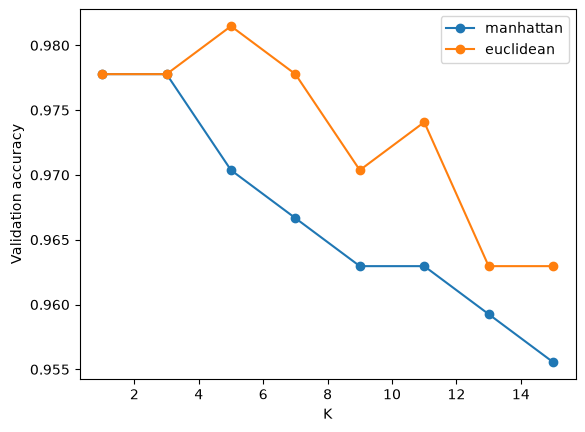

In [16]:
for metric in distance_metrics:
    metric_results = [
        result for result in results
        if result['Metric'] == metric
    ]

    k_plot = [result['K'] for result in metric_results]
    accuracy_plot = [result['Validation Accuracy'] for result in metric_results]

    plt.plot(
        k_plot,
        accuracy_plot,
        marker="o",
        label=metric
    )

plt.xlabel("K")
plt.ylabel("Validation accuracy")
plt.legend()
plt.show()

La curva permite observar que la mejor accuracy de validación corresponde a Euclídea con K=5

2.5 Evaluación final en prueba

Una vez elegidos la métrica y K usando validación:

unir entrenamiento y validación (X_train_final_d, y_train_final_d);
entrenar un nuevo KNeighborsClassifier con esos datos;
evaluar una sola vez sobre prueba (X_test_d, y_test_d).


In [17]:
X_train_final_d = np.concatenate(
    [X_train_d, X_val_d]
)

y_train_final_d = np.concatenate(
    [y_train_d, y_val_d]
)

knn_final = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

knn_final.fit(
    X_train_final_d,
    y_train_final_d
)

y_test_pred_d = knn_final.predict(X_test_d)

test_accuracy = accuracy_score(
    y_test_d,
    y_test_pred_d
)

print("Test accuracy:", test_accuracy)

Test accuracy: 0.9962962962962963


2.6 Matriz de confusión de Digits

Construir la matriz de confusión usando:

confusion_matrix(y_test_d, y_test_pred_d)

y ConfusionMatrixDisplay.

Recordar:

filas = clase real;
columnas = clase predicha;
diagonal principal = predicciones correctas.

Consignas:

Construya y grafique la matriz.
Identifique si algún dígito presenta errores.

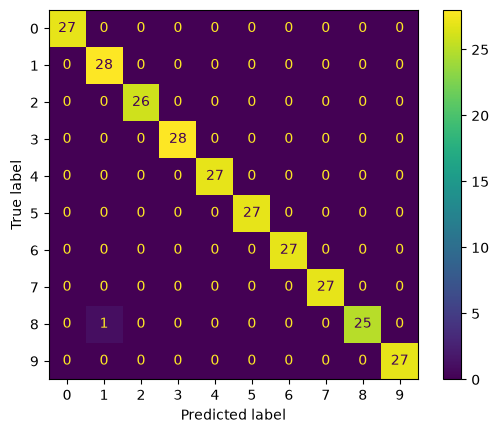

In [18]:
cm = confusion_matrix(
    y_test_d,
    y_test_pred_d
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

Sí. El dígito que presenta un error es el dígito 8. De las observaciones cuya clase real es 8, 25 fueron clasificadas correctamente como 8 y una fue clasificada como 1.

El resto de los dígitos no presenta errores en este conjunto de prueba, ya que sus valores se encuentran únicamente sobre la diagonal principal de la matriz de confusión.

Por lo tanto, la única confusión observada corresponde a una instancia de la clase 8 predicha como clase 1.


2.7 ¿Qué ocurre si hay un empate en la votación?

Analizaremos una observación particular del conjunto de prueba de Digits. Para ello utilizaremos temporalmente K = 4 y K = 5, manteniendo la distancia Euclídea.

La función kneighbors() permite consultar directamente cuáles son los vecinos utilizados por el clasificador y sus distancias.

Ejecutar el código proporcionado en la notebook y analizar los resultados.

Preguntas
¿Qué ocurre con la votación cuando K = 4?
¿Qué ocurre cuando K = 5?
¿Utilizar un valor impar de K garantiza que no pueda existir un empate?
¿Qué clase predice KNeighborsClassifier en cada caso?
Investigue: ¿qué criterios utiliza scikit-learn para resolver un empate entre clases?

K = 4
Neighbor labels: [6 6 8 8]
Distances: [23.79 24.45 27.51 29.24]
Prediction: 6

K = 5
Neighbor labels: [6 6 8 8 1]
Distances: [23.79 24.45 27.51 29.24 29.72]
Prediction: 6



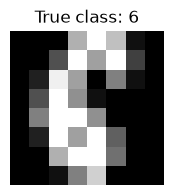

In [19]:
sample_index = 168
sample = X_test_d[sample_index].reshape(1, -1)

for k in [4, 5]:

    knn_tie = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean",
        weights="uniform"
    )

    knn_tie.fit(X_train_final_d, y_train_final_d)

    distances, indices = knn_tie.kneighbors(sample)
    neighbor_labels = y_train_final_d[indices[0]]
    prediction = knn_tie.predict(sample)[0]

    print(f"K = {k}")
    print("Neighbor labels:", neighbor_labels)
    print("Distances:", np.round(distances[0], 2))
    print("Prediction:", prediction)
    print()


plt.figure(figsize=(2, 2))
plt.imshow(X_test_d[sample_index].reshape(8, 8), cmap="gray")
plt.title(f"True class: {y_test_d[sample_index]}")
plt.axis("off")
plt.show()

1. los vecinos son  [6 6 8 8]. 2 votos para 6 y 2 para 8, se produce un empate

2. los vecinos son [6 6 8 8 1]. También se produce un empate. 

3. No. Utilizar un valor impar de K evita los empates en un problema binario, porque los votos se distribuyen entre solamente dos clases y una de ellas necesariamente obtiene la mayoría.
Sin embargo, en un problema multiclase sí puede existir un empate con K impar. En el ejemplo analizado, con K = 5, los vecinos pertenecen a las clases 6, 6, 8, 8 y 1. Las clases 6 y 8 obtienen dos votos cada una, mientras que la clase 1 obtiene un voto. Por lo tanto, existe un empate entre las clases 6 y 8

4. K = 4 → predice 6 K = 5 → predice 6

5. Cuando KNeighborsClassifier utiliza weights="uniform", todos los vecinos tienen el mismo peso y la predicción se obtiene a partir de la votación de sus clases.

Cuando existe un empate entre clases, scikit-learn necesita aplicar un criterio adicional para seleccionar una única clase. En este caso, las clases están representadas numéricamente y el desempate favorece la clase que aparece primero en el orden de las clases.
Esto explica el resultado observado: para K = 4 existe un empate entre las clases 6 y 8 y se predice la clase 6. Para K = 5 también existe un empate entre 6 y 8, por lo que nuevamente se predice 6.


##  ACTIVIDAD 3: El dataset Breast Cancer Wisconsin Diagnostic contiene información obtenida a partir de imágenes digitalizadas de muestras celulares de masas mamarias. Su objetivo es distinguir entre tumores benignos y malignos.

Para facilitar la interpretación de las métricas, se recodificará la variable objetivo como:

1 = maligno = clase positiva
0 = benigno = clase negativa

Esto es importante porque precision y recall siempre se interpretan respecto de una clase positiva.

3.1 División y escalado

Dividir en entrenamiento y prueba utilizando:

test_size=0.20
random_state=42
stratify=y_cancer

Luego construir un pipeline:

StandardScaler
KNeighborsClassifier

con:

n_neighbors=5
metric="euclidean"

In [20]:
cancer = load_breast_cancer(as_frame=True)

X_cancer = cancer.data

# Recodificado para que maligno sea la clase positiva
y_cancer = (cancer.target == 0).astype(int)

print("Positive class: malignant = 1")
print("Negative class: benign = 0")
print(y_cancer.value_counts().sort_index())

Positive class: malignant = 1
Negative class: benign = 0
target
0    357
1    212
Name: count, dtype: int64


3.2 Matriz de confusión

Construir la matriz de confusión.

Luego identificar:

VP
VN
FP
FN

Responder:

En este problema, ¿qué representa un falso negativo?

In [21]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer,
    y_cancer,
    test_size=0.20,
    random_state=42,
    stratify=y_cancer
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=5,
        metric="euclidean"
    ))
])

pipe.fit(X_train_c, y_train_c)

y_pred_c = pipe.predict(X_test_c)

[[71  1]
 [ 4 38]]


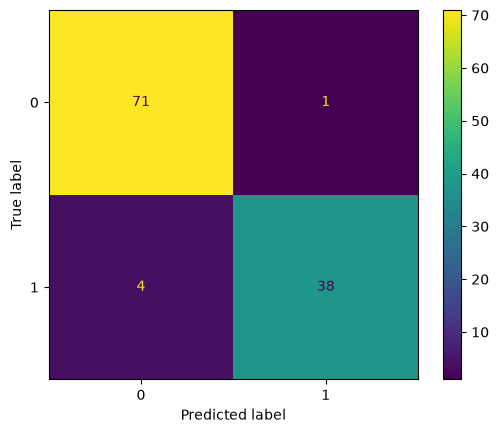

In [22]:
cm_cancer = confusion_matrix(
    y_test_c,
    y_pred_c
)

print(cm_cancer)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cancer
)

disp.plot()
plt.show()


VN = 71
FP = 1
FN = 4
VP = 38

En este problema, un falso negativo corresponde a un caso que realmente es maligno pero que el modelo clasifica como benigno.
Como la clase positiva fue definida como maligno = 1, un falso negativo significa que el modelo no detectó un tumor maligno. En la matriz de confusión obtenida hay 4 falsos negativos.
Este tipo de error es especialmente importante en este problema porque implica que un caso maligno podría ser considerado erróneamente como benigno.

3.3 Accuracy, precision, recall y F1
Calcular:
accuracy_score
precision_score
recall_score
f1_score

Recordar que la clase positiva es malignant = 1.
Responder: Si el objetivo principal fuera reducir los casos malignos no detectados, ¿qué métrica debería observarse especialmente?
¿Por qué un modelo con accuracy alta puede seguir siendo inadecuado para una aplicación concreta?

In [23]:
accuracy = accuracy_score(
    y_test_c,
    y_pred_c
)

precision = precision_score(
    y_test_c,
    y_pred_c
)

recall = recall_score(
    y_test_c,
    y_pred_c
)

f1 = f1_score(
    y_test_c,
    y_pred_c
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Accuracy: 0.956140350877193
Precision: 0.9743589743589743
Recall: 0.9047619047619048
F1: 0.9382716049382716


La métrica que debería observarse especialmente es el recall.
En este problema, la clase positiva es maligno = 1. El recall mide qué proporción de todos los casos realmente malignos logró detectar correctamente el modelo:

Recall = VP / (VP + FN)

Por lo tanto, aumentar el recall permite reducir los falsos negativos, que en este contexto corresponden a tumores malignos que el modelo clasifica incorrectamente como benignos.
En este caso, el recall obtenido es de aproximadamente 90,48 %.

Una accuracy alta no garantiza que el modelo sea adecuado para una aplicación concreta porque la accuracy considera globalmente las predicciones correctas y no distingue entre los diferentes tipos de error.

En una aplicación médica, por ejemplo, un falso negativo puede ser mucho más grave que un falso positivo. Un modelo podría tener una accuracy elevada y, al mismo tiempo, presentar demasiados casos malignos clasificados como benignos.
Por eso, la métrica debe seleccionarse de acuerdo con el objetivo y con el costo de los errores. En este problema, además de la accuracy, resulta especialmente importante observar el recall, ya que permite evaluar qué proporción de los casos malignos fue detectada correctamente.